## Instalação de Dependências

In [ ]:
# !pip install yfinance

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Bidirectional
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import TimeSeriesSplit
import itertools
import pandas as pd

## Obtenção e Análise dos Dados

Nesta seção realizamos o download dos dados históricos da ação via `yfinance`, inspecionamos a estrutura do DataFrame e justificamos a escolha do **`StandardScaler`** para a normalização das features.


In [3]:
symbol     = 'BBD'
start_date = '2020-06-01'
end_date   = '2026-06-01'

df = yf.download(symbol, start=start_date, end=end_date)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BBD,BBD,BBD,BBD,BBD
Date,,,,,
2020-06-01,2.571659,2.614049,2.508074,2.529269,17004600
2020-06-02,2.807119,2.807119,2.672773,2.686915,18023200
2020-06-03,2.990960,3.075810,2.962677,3.019243,26336600
2020-06-04,3.012171,3.061667,2.891967,2.927321,25679800
2020-06-05,3.181872,3.309147,3.132376,3.287935,24705200
...,...,...,...,...,...
2026-05-22,3.466046,3.545954,3.456057,3.525977,26085300
2026-05-26,3.535966,3.555943,3.476034,3.555943,28540400


### Refatorando Colunas do DataFrame

O `yfinance` retorna um MultiIndex (tipo de preço × ticker). Vamos simplificar para um único nível de colunas e converter o índice `Date` em coluna regular.

In [4]:
df.columns = df.columns.get_level_values(0)
df.reset_index(inplace=True)

print('DataFrame com colunas refatoradas:')
display(df.head())

DataFrame com colunas refatoradas:


Price,Date,Close,High,Low,Open,Volume
0,2020-06-01,2.571659,2.614049,2.508074,2.529269,17004600
1,2020-06-02,2.807119,2.807119,2.672773,2.686915,18023200
2,2020-06-03,2.990960,3.075810,2.962677,3.019243,26336600
3,2020-06-04,3.012171,3.061667,2.891967,2.927321,25679800
4,2020-06-05,3.181872,3.309147,3.132376,3.287935,24705200


### Análise das Colunas do DataFrame

O DataFrame contém dados históricos de preços da ação **ITUB** obtidos via `yfinance`. Abaixo, a descrição de cada coluna e seu uso potencial no modelo:

| Coluna | Descrição | Uso no Modelo |
|--------|-----------|---------------|
| **`Close`** | Preço de fechamento (ajustado) | Target principal do LSTM |
| **`High`** | Máxima do dia | Feature de volatilidade |
| **`Low`** | Mínima do dia | Feature de volatilidade |
| **`Open`** | Preço de abertura | Feature de tendência intraday |
| **`Volume`** | Quantidade de ações negociadas | Feature de liquidez/convicção |

### Série Temporal do Preço de Fechamento

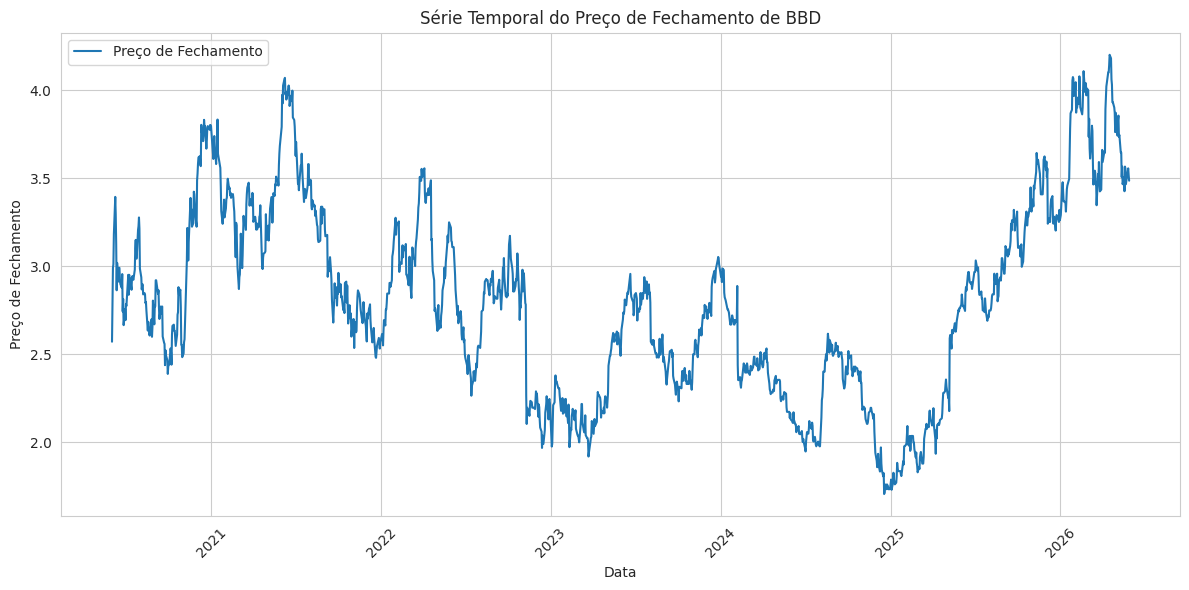

In [5]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Preço de Fechamento')
plt.title(f'Série Temporal do Preço de Fechamento de {symbol}')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribuição e Estatísticas Descritivas

Estatísticas Descritivas das Colunas Numéricas:


Price,Close,High,Low,Open,Volume
count,1507.000000,1507.000000,1507.000000,1507.000000,1.507000e+03
mean,2.794045,2.835248,2.755827,2.794384,3.087369e+07
std,0.542083,0.550309,0.534874,0.543938,1.620792e+07
min,1.706780,1.743288,1.679398,1.706779,4.483100e+06
25%,2.380189,2.417411,2.352409,2.382050,1.970535e+07
50%,2.764683,2.805035,2.731682,2.767430,2.804190e+07
75%,3.196416,3.238057,3.134877,3.175629,3.863055e+07
max,4.200822,4.290626,4.190844,4.290626,1.871755e+08


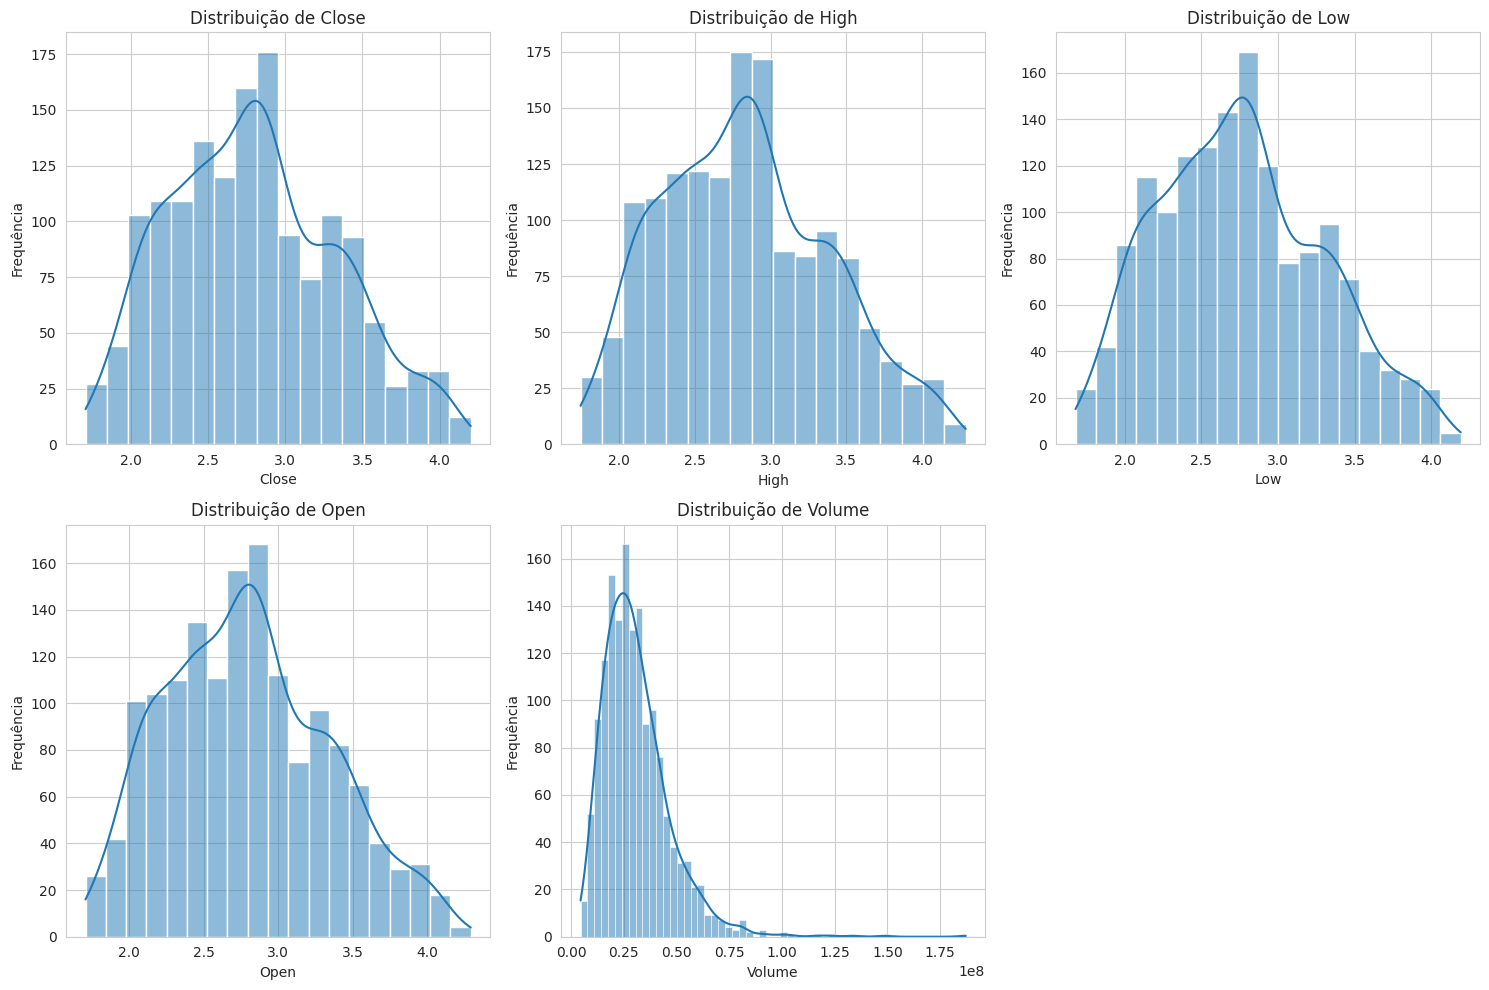

In [6]:
numerical_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
df_numerical = df[numerical_cols]

print('Estatísticas Descritivas das Colunas Numéricas:')
display(df_numerical.describe())

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_numerical[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### Boxplots — Visualização de Outliers

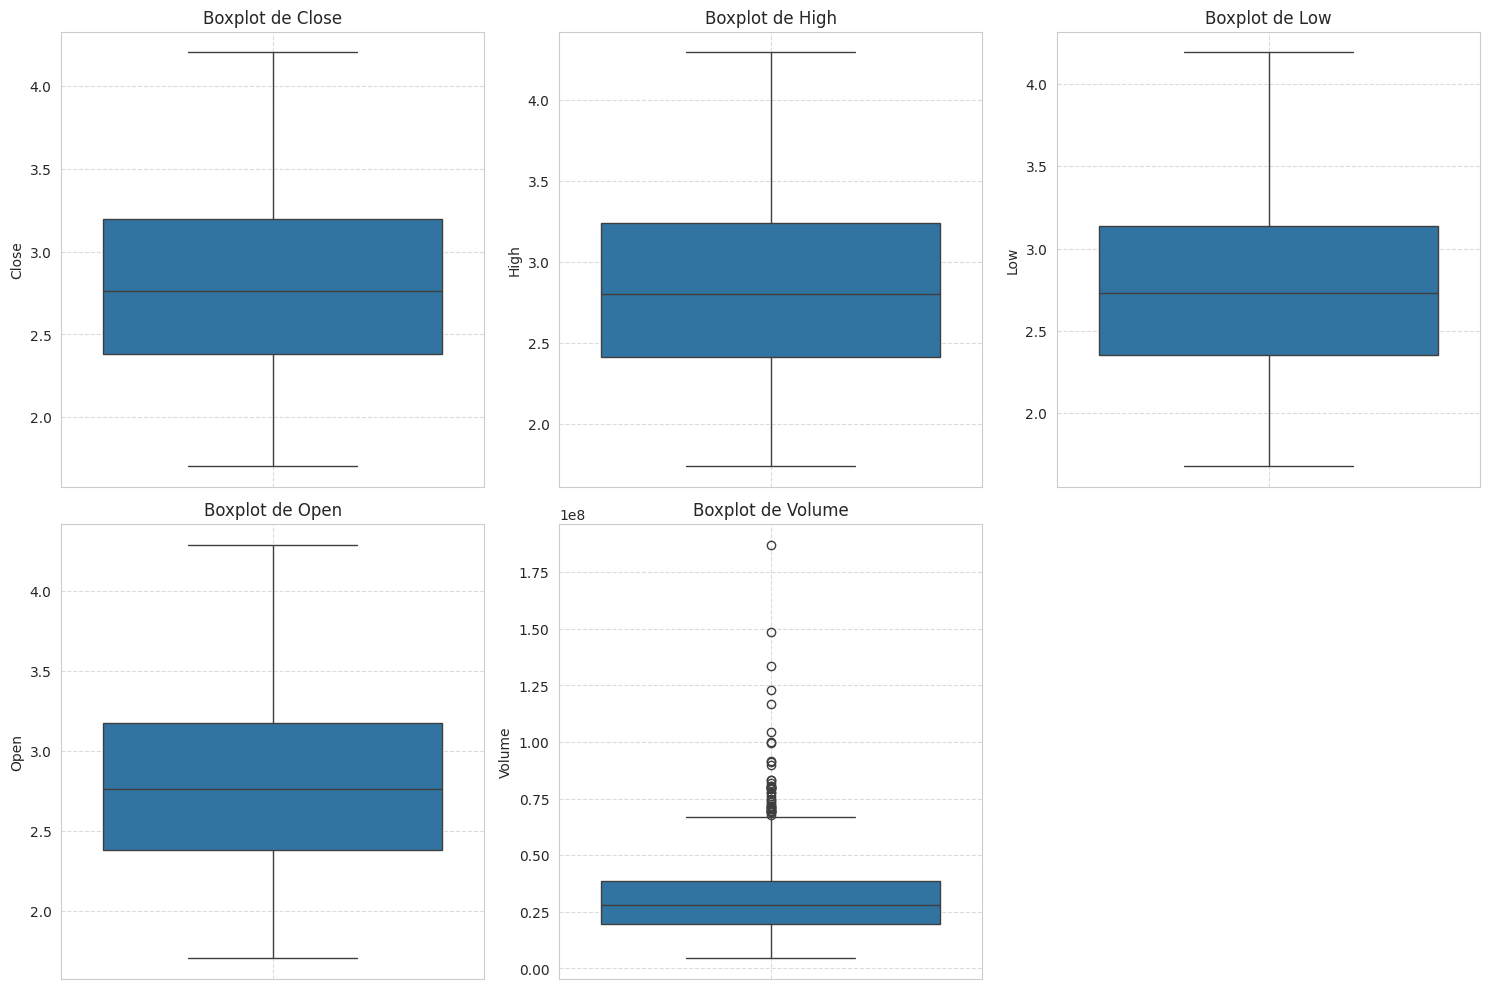

In [7]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análise Quantitativa de Outliers — `Close`

In [8]:
print('Quartis para os Preços de Fechamento:')
print(df['Close'].describe()[['25%', '50%', '75%']])

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df['Close'][(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print('\nOutliers nos Preços de Fechamento:')
if not outliers.empty:
    display(outliers)
else:
    print('Nenhum outlier encontrado.')

total_data_points = len(df['Close'])
num_outliers = len(outliers)
if total_data_points > 0:
    percentage_outliers = (num_outliers / total_data_points) * 100
    print(f'\nPorcentagem de outliers nos Preços de Fechamento: {percentage_outliers:.2f}%')

Quartis para os Preços de Fechamento:
25%    2.380189
50%    2.764683
75%    3.196416
Name: Close, dtype: float64

Outliers nos Preços de Fechamento:
Nenhum outlier encontrado.

Porcentagem de outliers nos Preços de Fechamento: 0.00%


### Justificativa para o Uso do `StandardScaler`

A análise exploratória revela que, após a transformação `log1p` aplicada às variáveis de preço e volume, as distribuições ficam suficientemente simétricas para justificar o uso do `StandardScaler`.

#### O que os histogramas mostram (pós-log)

Após a transformação logarítmica:

- **`Close`, `High`, `Low`, `Open`**: a compressão da cauda direita aproxima as distribuições de uma forma unimodal e mais simétrica, reduzindo o skewness de forma significativa.
- **`Volume`**: o `log1p` converte a distribuição fortemente assimétrica (cauda até 175 M) em uma curva muito mais comportada, com skewness próximo de zero.

#### Por que o `StandardScaler` é adequado neste contexto

O `StandardScaler` centraliza cada feature em torno da média com desvio-padrão unitário — premissa que se sustenta quando a distribuição é aproximadamente simétrica e sem outliers extremos. Após o `log1p`:

- A assimetria das séries originais é corrigida, tornando a média uma medida de tendência central confiável.
- Os outliers extremos de Volume (que antes chegavam a 3× o Q3) são atenuados pelo log, reduzindo seu impacto sobre o desvio-padrão.
- O `StandardScaler` produz features com escala comparável entre si, o que beneficia a convergência do otimizador Adam e a estabilidade dos gradientes na LSTM.

| Scaler | Baseia-se em | Sensível a Outliers? | Adequado pós-log? |
|--------|-------------|----------------------|-------------------|
| `MinMaxScaler` | Min / Max | ✅ Muito | ❌ Outliers residuais ainda comprimem a escala |
| **`StandardScaler`** | **Média / Desvio-padrão** | **⚠️ Moderado** | **✅ Adequado quando a distribuição pós-log é aproximadamente simétrica** |
| `RobustScaler` | Mediana / IQR | ❌ Pouco | ✅ Alternativa conservadora, mas desnecessária quando o log já corrigiu a assimetria |


## Pré-processamento

As colunas utilizadas no modelo são as originais do `yfinance` — sem indicadores técnicos derivados:

| Coluna | Descrição | Uso no Modelo |
|--------|-----------|---------------|
| `Close` | Preço de fechamento | Target e feature principal |
| `High` | Máxima do dia | Feature de volatilidade |
| `Low` | Mínima do dia | Feature de volatilidade |
| `Open` | Preço de abertura | Feature de tendência intraday |
| `Volume` | Quantidade negociada | Feature de liquidez |


In [9]:
# Sem engenharia de features: apenas as colunas originais do yfinance
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape após limpeza: {df.shape}')
display(df.head())


Shape após limpeza: (1507, 6)


Price,Date,Close,High,Low,Open,Volume
0,2020-06-01,2.571659,2.614049,2.508074,2.529269,17004600
1,2020-06-02,2.807119,2.807119,2.672773,2.686915,18023200
2,2020-06-03,2.990960,3.075810,2.962677,3.019243,26336600
3,2020-06-04,3.012171,3.061667,2.891967,2.927321,25679800
4,2020-06-05,3.181872,3.309147,3.132376,3.287935,24705200


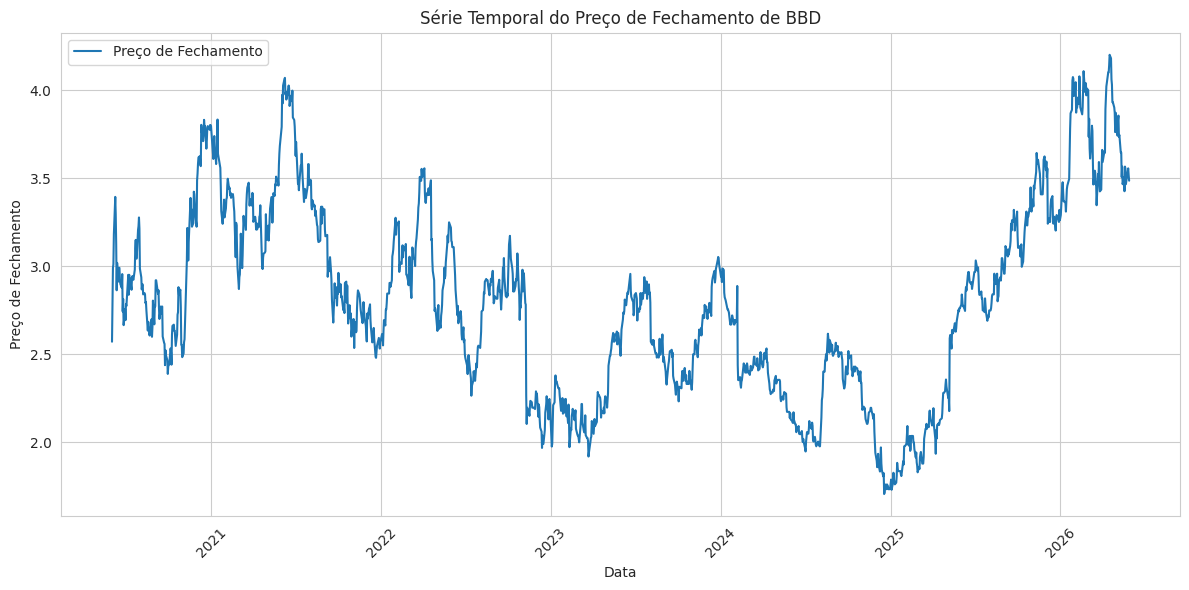

In [10]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Preço de Fechamento')
plt.title(f'Série Temporal do Preço de Fechamento de {symbol}')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Seleção de Features e Normalização

O pipeline de normalização segue **duas etapas sequenciais**:

1. **Transformação logarítmica** (`log1p`) aplicada aos preços OHLC e ao Volume — comprime caudas longas e simetriza as distribuições antes do scaler.
2. **`StandardScaler`** ajustado **apenas nos dados de treino** (`fit_transform`) e reutilizado nos dados de validação e teste (`transform`) — evita *data leakage* e é adequado após o `log1p` ter corrigido a assimetria das distribuições.

Features com alta colinearidade (`BB_Upper`, `BB_Lower`, `MA_7`, `MA_21` brutos) são omitidas — `Ratio_MA7_MA21`, `BB_Position` e `BB_Width` capturam as mesmas informações de forma mais estável.


In [11]:
# Aplicar log1p a Volume (skewness extremo) e às colunas de preço (variância não-estacionária)
# log1p(x) = ln(1 + x) → nunca produz NaN para valores >= 0
price_cols = ['Close', 'High', 'Low', 'Open']
df[price_cols] = np.log1p(df[price_cols])
df['Volume']   = np.log1p(df['Volume'])

print('Distribuição após log1p (estatísticas descritivas):')
display(df[['Close', 'High', 'Low', 'Open', 'Volume']].describe())

# Verificar simetria: o skewness deve cair significativamente após o log
print('\nSkewness antes do scaler (pós-log):')
print(df[['Close', 'High', 'Low', 'Open', 'Volume']].skew().round(3))


Distribuição após log1p (estatísticas descritivas):


Price,Close,High,Low,Open,Volume
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,1.323288,1.334002,1.313228,1.323313,17.121727
std,0.142496,0.143104,0.142050,0.142940,0.504513
min,0.995760,1.009157,0.985592,0.995759,15.315826
25%,1.217932,1.228883,1.209679,1.218482,16.796401
50%,1.325664,1.336325,1.316859,1.326393,17.149210
75%,1.434231,1.444105,1.419458,1.429265,17.469554
max,1.648817,1.665937,1.646896,1.665937,19.047557



Skewness antes do scaler (pós-log):
Price
Close     0.023
High      0.023
Low       0.020
Open      0.024
Volume   -0.207
dtype: float64


In [12]:
FEATURE_COLS = ['Close', 'High', 'Low', 'Open', 'Volume']

data = df[FEATURE_COLS].values
num_features = data.shape[1]
print(f'Total de features: {num_features}')

train_size = int(len(data) * 0.70)
val_size   = int(len(data) * 0.15)

train_raw = data[:train_size]
val_raw   = data[train_size:train_size + val_size]
test_raw  = data[train_size + val_size:]

# StandardScaler: centraliza em média=0, std=1 — adequado pois o log1p já simetrizou as distribuições
scaler       = StandardScaler()
train_scaled = scaler.fit_transform(train_raw)   # fit APENAS no treino → sem data leakage
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

print(f'Treino: {len(train_scaled)} amostras')
print(f'Val:    {len(val_scaled)} amostras')
print(f'Teste:  {len(test_scaled)} amostras')


Total de features: 5
Treino: 1054 amostras
Val:    226 amostras
Teste:  227 amostras


### Distribuição das Variáveis Pós-Normalização

Os painéis abaixo comparam lado a lado a distribuição de cada variável nos três conjuntos (treino, validação, teste) após `log1p` + `StandardScaler`. Espera-se:
- Média ≈ 0 e desvio-padrão ≈ 1 (confirmando o scaler)
- Curvas de validação e teste alinhadas com a de treino (sem drift de distribuição)


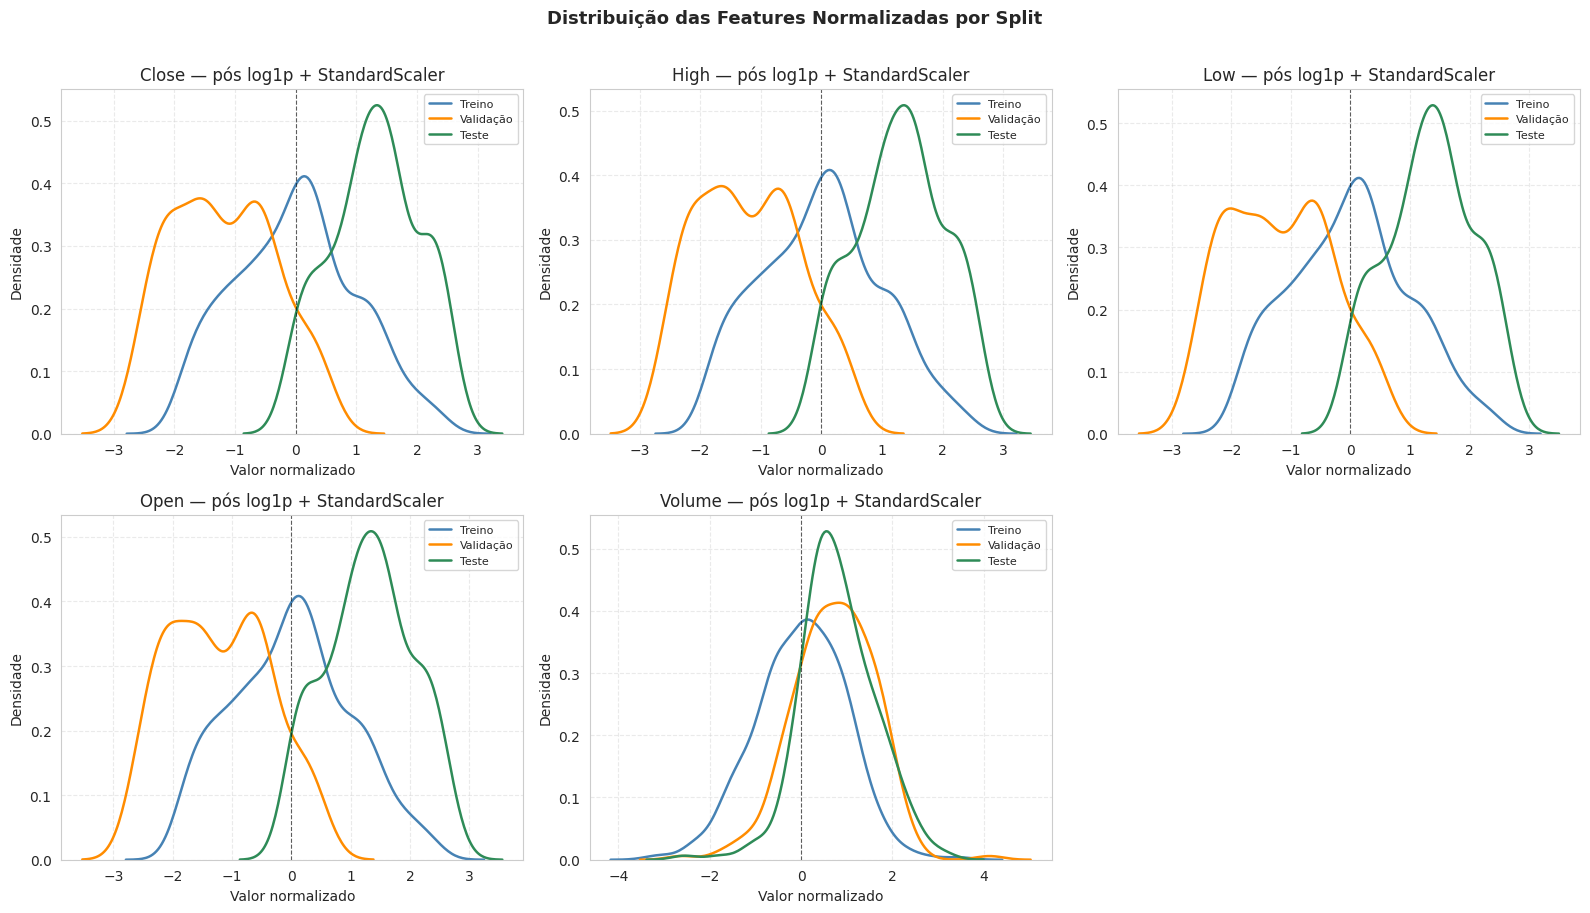

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

splits = [
    ('Treino',    train_scaled),
    ('Validação', val_scaled),
    ('Teste',     test_scaled),
]
colors = ['steelblue', 'darkorange', 'seagreen']

for ax_idx, col_name in enumerate(FEATURE_COLS):
    ax = axes[ax_idx]
    col_i = FEATURE_COLS.index(col_name)
    for (label, split_data), color in zip(splits, colors):
        sns.kdeplot(split_data[:, col_i], ax=ax, label=label, color=color, linewidth=1.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{col_name} — pós log1p + StandardScaler')
    ax.set_xlabel('Valor normalizado')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Distribuição das Features Normalizadas por Split', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


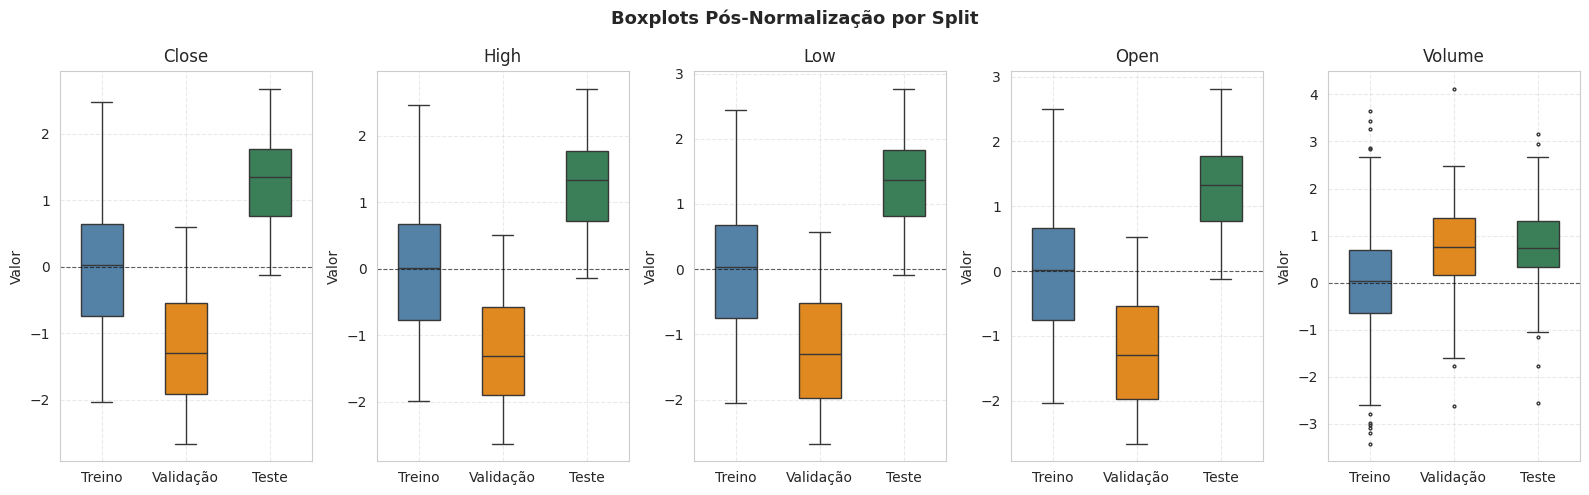

In [14]:
fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 5))

import pandas as pd
for ax_idx, col_name in enumerate(FEATURE_COLS):
    col_i = FEATURE_COLS.index(col_name)
    df_box = pd.DataFrame({
        'Treino':    train_scaled[:, col_i],
        'Validação': np.pad(val_scaled[:, col_i],   (0, len(train_scaled) - len(val_scaled)),   constant_values=np.nan),
        'Teste':     np.pad(test_scaled[:, col_i],  (0, len(train_scaled) - len(test_scaled)),  constant_values=np.nan),
    })
    df_box_melted = df_box.melt(var_name='Split', value_name='Valor').dropna()
    sns.boxplot(
        data=df_box_melted, x='Split', y='Valor', ax=axes[ax_idx],
        palette={'Treino': 'steelblue', 'Validação': 'darkorange', 'Teste': 'seagreen'},
        width=0.5, fliersize=2
    )
    axes[ax_idx].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[ax_idx].set_title(col_name)
    axes[ax_idx].set_xlabel('')
    axes[ax_idx].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Boxplots Pós-Normalização por Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

rows = []
for split_name, split_data in [('Treino', train_scaled), ('Validação', val_scaled), ('Teste', test_scaled)]:
    df_split = pd.DataFrame(split_data, columns=FEATURE_COLS)
    stats = df_split.agg(['mean', 'std', 'skew']).T
    stats.columns = ['Média', 'Std', 'Skewness']
    stats['Split'] = split_name
    rows.append(stats.reset_index().rename(columns={'index': 'Feature'}))

df_stats = pd.concat(rows).set_index(['Feature', 'Split'])
print('Estatísticas pós-normalização (média ≈ 0, std ≈ 1 esperados no treino):')
display(df_stats.round(4))


Estatísticas pós-normalização (média ≈ 0, std ≈ 1 esperados no treino):


,,Média,Std,Skewness
Feature,Split,,,
Close,Treino,0.0000,1.0005,0.1339
High,Treino,0.0000,1.0005,0.1244
Low,Treino,-0.0000,1.0005,0.1338
Open,Treino,0.0000,1.0005,0.1344
Volume,Treino,-0.0000,1.0005,-0.1251
Close,Validação,-1.1880,0.8476,0.1807
High,Validação,-1.2035,0.8377,0.1811
Low,Validação,-1.1900,0.8612,0.1709
Open,Validação,-1.2088,0.8497,0.1686


#### Recuperação do Preço Original (inverse transform pós-log)

Como o target `Close` foi transformado por `log1p` antes do scaler, a inversão precisa de **dois passos**:

1. `scaler.inverse_transform(...)` — desfaz o `StandardScaler` (retorna escala log)
2. `np.expm1(...)` — desfaz o `log1p` (retorna preço em BRL)

Isso é encapsulado na função `inverse_close` abaixo.


In [16]:
def inverse_close(arr_1d, scaler, num_features):
    """Inverte StandardScaler + log1p para obter preço em BRL."""
    dummy = np.zeros((len(arr_1d), num_features))
    dummy[:, 0] = arr_1d
    log_prices = scaler.inverse_transform(dummy)[:, 0]
    return np.expm1(log_prices)  # desfaz log1p

print('Função inverse_close definida — aplica inverse_transform + expm1.')


Função inverse_close definida — aplica inverse_transform + expm1.


In [17]:
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, :])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

### Callback de MAPE em Escala Real

Para que o `EarlyStopping` e o `ReduceLROnPlateau` operem sobre o MAPE calculado nos preços originais (e não na escala normalizada), definimos um callback customizado que aplica o `inverse_transform` ao final de cada época de validação.

In [18]:
class RealMapeCallback(Callback):
    def __init__(self, X_val, y_val, scaler, num_features):
        super().__init__()
        self.X_val        = X_val
        self.y_val        = y_val
        self.scaler       = scaler
        self.num_features = num_features

    def _inverse_close(self, arr_1d):
        dummy = np.zeros((len(arr_1d), self.num_features))
        dummy[:, 0] = arr_1d
        return self.scaler.inverse_transform(dummy)[:, 0]

    def on_epoch_end(self, epoch, logs=None):
        preds_scaled = self.model.predict(self.X_val, verbose=0).flatten()
        y_pred_orig  = self._inverse_close(preds_scaled)
        y_true_orig  = self._inverse_close(self.y_val)
        mape_real    = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100
        logs['val_mape_real'] = mape_real

## Validação de Hiperparâmetros com TimeSeriesSplit

O K-Fold convencional **não pode ser usado** em séries temporais pois embaralha os dados, permitindo que o modelo treine com informações do futuro (*data leakage*). O `TimeSeriesSplit` resolve isso garantindo que cada fold de validação seja **sempre posterior** ao treino.

### Grade de Hiperparâmetros


In [ ]:
PARAM_GRID = {
    'look_back':  [30, 60, 90],
    'units':      [64, 128, 256],
    'dropout':    [0.1, 0.2, 0.3],
    'batch_size': [16, 32],
}

combinations = list(itertools.product(
    PARAM_GRID['look_back'],
    PARAM_GRID['units'],
    PARAM_GRID['dropout'],
    PARAM_GRID['batch_size']
))

print(f'Total de combinações a avaliar: {len(combinations)}')

Total de combinações a avaliar: 54


In [ ]:
def build_model_search(look_back, num_features, units, dropout_rate):
    m = Sequential([
        Bidirectional(
            LSTM(units, return_sequences=True, kernel_regularizer=l2(1e-5)),
            input_shape=(look_back, num_features)
        ),
        BatchNormalization(),
        Dropout(dropout_rate),
        LSTM(units // 2, return_sequences=False, kernel_regularizer=l2(1e-5)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(1)
    ])
    m.compile(optimizer=Adam(learning_rate=1e-3), loss='mae')
    return m

### Busca com TimeSeriesSplit (5 folds)

In [ ]:
N_SPLITS      = 5
SEARCH_EPOCHS = 25
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

es_search = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=0
)

results = []

for look_back_s, units_s, dropout_s, batch_size_s in combinations:
    fold_losses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(df)):
        df_fold_train = df.iloc[train_idx].copy()
        df_fold_val   = df.iloc[val_idx].copy()


        raw_train = df_fold_train[FEATURE_COLS].values
        raw_val   = df_fold_val[FEATURE_COLS].values

        sc_fold = StandardScaler()
        s_train = sc_fold.fit_transform(raw_train)
        s_val   = sc_fold.transform(raw_val)

        Xf_tr,  yf_tr  = create_sequences(s_train, look_back_s)
        Xf_val, yf_val = create_sequences(s_val,   look_back_s)

        if len(Xf_tr) == 0 or len(Xf_val) == 0:
            continue

        m = build_model_search(look_back_s, num_features, units_s, dropout_s)
        m.fit(
            Xf_tr, yf_tr,
            epochs=SEARCH_EPOCHS,
            batch_size=batch_size_s,
            validation_data=(Xf_val, yf_val),
            callbacks=[es_search],
            verbose=0
        )
        fold_losses.append(min(m.history.history['val_loss']))
        tf.keras.backend.clear_session()

    if fold_losses:
        mean_loss = np.mean(fold_losses)
        std_loss  = np.std(fold_losses)
        results.append({
            'look_back':     look_back_s,
            'units':         units_s,
            'dropout':       dropout_s,
            'batch_size':    batch_size_s,
            'mean_val_loss': mean_loss,
            'std_val_loss':  std_loss,
        })
        print(f'look_back={look_back_s:3d} | units={units_s:3d} | dropout={dropout_s} | batch_size={batch_size_s} '
              f'-> val_loss={mean_loss:.5f} +/- {std_loss:.5f}')

print('\nBusca concluída.')

look_back= 30 | units= 64 | dropout=0.1 | batch_size=16 -> val_loss=0.65956 +/- 0.43429
look_back= 30 | units= 64 | dropout=0.1 | batch_size=32 -> val_loss=1.02904 +/- 0.40538
look_back= 30 | units= 64 | dropout=0.2 | batch_size=16 -> val_loss=0.70795 +/- 0.37669
look_back= 30 | units= 64 | dropout=0.2 | batch_size=32 -> val_loss=0.89341 +/- 0.32440
look_back= 30 | units= 64 | dropout=0.3 | batch_size=16 -> val_loss=0.59911 +/- 0.29731
look_back= 30 | units= 64 | dropout=0.3 | batch_size=32 -> val_loss=0.89248 +/- 0.44277
look_back= 30 | units=128 | dropout=0.1 | batch_size=16 -> val_loss=0.65597 +/- 0.33667
look_back= 30 | units=128 | dropout=0.1 | batch_size=32 -> val_loss=0.96772 +/- 0.34876
look_back= 30 | units=128 | dropout=0.2 | batch_size=16 -> val_loss=0.71233 +/- 0.48346
look_back= 30 | units=128 | dropout=0.2 | batch_size=32 -> val_loss=1.00387 +/- 0.47195
look_back= 30 | units=128 | dropout=0.3 | batch_size=16 -> val_loss=0.56794 +/- 0.37575
look_back= 30 | units=128 | drop

In [1]:
results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
print('Ranking de hiperparâmetros (menor val_loss = melhor):')
display(results_df)

best = results_df.iloc[0]
BEST_LOOK_BACK  = int(best['look_back'])
BEST_UNITS      = int(best['units'])
BEST_DROPOUT    = float(best['dropout'])
BEST_BATCH_SIZE = int(best['batch_size'])

print(f'\nMelhores hiperparâmetros:')
print(f'  look_back  = {BEST_LOOK_BACK}')
print(f'  units      = {BEST_UNITS}')
print(f'  dropout    = {BEST_DROPOUT}')
print(f'  batch_size = {BEST_BATCH_SIZE}')

NameError: name 'pd' is not defined

In [ ]:
best_dropout_val = results_df.groupby('dropout')['mean_val_loss'].mean().idxmin()
pivot = (
    results_df[results_df['dropout'] == best_dropout_val]
    .pivot(index='look_back', columns=['units', 'batch_size'], values='mean_val_loss')
)

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.5f', cmap='YlOrRd_r', linewidths=0.5)
plt.title(f'Val Loss por Look-back x Units (dropout={best_dropout_val})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
labels = [
    f'lb={r.look_back}\nu={r.units}\nd={r.dropout}'
    for _, r in results_df.iterrows()
]
ax.bar(labels, results_df['mean_val_loss'],
       yerr=results_df['std_val_loss'], capsize=4,
       color='steelblue', alpha=0.7)
ax.set_ylabel('Val Loss (MAE normalizado)')
ax.set_title('Comparação de Hiperparâmetros — mean ± std across folds')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

### Atualização do Split com os Melhores Hiperparâmetros

Com o `look_back` ótimo definido pela busca, recriamos as sequências de treino, validação e teste antes do treinamento final.

In [ ]:
look_back= 90 | units= 64 | dropout=0.1 | batch_size=16 -> val_loss=0.51703 +/- 0.27275
look_back= 90 | units=256 | dropout=0.1 | batch_size=16 -> val_loss=0.51087 +/- 0.31168
look_back= 30 | units= 64 | dropout=0.3 | batch_size=16 -> val_loss=0.59911 +/- 0.29731
look_back= 30 | units=128 | dropout=0.3 | batch_size=16 -> val_loss=0.56794 +/- 0.37575

In [30]:
BEST_LOOK_BACK = 30
BEST_UNITS     = 128
BEST_DROPOUT   = 0.3
BEST_BATCH_SIZE = 16

In [31]:
LOOK_BACK = BEST_LOOK_BACK

X_train, y_train = create_sequences(train_scaled, LOOK_BACK)
X_val,   y_val   = create_sequences(val_scaled,   LOOK_BACK)
X_test,  y_test  = create_sequences(test_scaled,  LOOK_BACK)

print(f'LOOK_BACK final: {LOOK_BACK}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

LOOK_BACK final: 30
X_train: (1024, 30, 5) | X_val: (196, 30, 5) | X_test: (197, 30, 5)


In [32]:
test_scaled.shape

(227, 5)

## Treinamento Robusto do Modelo LSTM

### Arquitetura — Bidirectional LSTM com Regularização

| Componente | Configuração |
|------------|-------------|
| **Bidirectional LSTM** | Aprende padrões em ambas as direções temporais |
| **BatchNormalization** | Estabiliza e acelera o treinamento |
| **Regularização L2** | Apenas nas camadas recorrentes — não na Dense final |
| **EarlyStopping** | Monitor `val_mape_real` — MAPE em escala original |
| **ReduceLROnPlateau** | Reduz o learning rate em platôs |
| **Split 70/15/15** | Conjunto de validação independente do teste |

In [33]:
def build_model(look_back, num_features, units, dropout_rate):
    model = Sequential([
        Bidirectional(
            LSTM(units//2, return_sequences=True, kernel_regularizer=l2(1e-6)),
            input_shape=(look_back, num_features)
        ),
        BatchNormalization(),
        Dropout(dropout_rate),
        LSTM(units // 2, return_sequences=False, kernel_regularizer=l2(1e-6)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dropout(dropout_rate * 0.5),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mae',
        metrics=['mape']
    )
    return model

model = build_model(LOOK_BACK, num_features, BEST_UNITS, BEST_DROPOUT)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 30, 128)        │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,073 (340.13 KB)

 Trainable params: 86,689 (338.63 KB)

 Non-trainable params: 384 (1.50 KB)

### Callbacks de Treinamento

- **`RealMapeCallback`**: calcula o MAPE sobre preços reais ao final de cada época de validação.
- **EarlyStopping** (`patience=20`, monitor `val_mape_real`): interrompe quando o MAPE real para de melhorar.
- **ReduceLROnPlateau** (`patience=5`): divide o learning rate por 2 em platôs.
- **ModelCheckpoint**: salva o melhor modelo em disco.

In [34]:
mape_cb = RealMapeCallback(X_val, y_val, scaler, num_features)

callbacks = [
    mape_cb,
    EarlyStopping(
        monitor='val_mape_real',
        patience=20,
        restore_best_weights=True,
        mode='min',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_mape_real',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='min',
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_mape_real',
        save_best_only=True,
        mode='min',
        verbose=0
    )
]

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=BEST_BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f'\nTreinamento encerrado na época: {len(history.history["loss"])}')
print(f'Melhor val_loss (MAE norm.): {min(history.history["val_loss"]):.6f}')
print(f'Melhor val_mape_real:        {min(history.history["val_mape_real"]):.4f}%')

Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 0.8804 - mape: 681.6787 - val_loss: 1.0976 - val_mape: 103.1417 - val_mape_real: 12.2243 - learning_rate: 1.0000e-04
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.6046 - mape: 427.0665 - val_loss: 0.9654 - val_mape: 85.3339 - val_mape_real: 10.7670 - learning_rate: 1.0000e-04
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.5654 - mape: 325.8871 - val_loss: 0.8825 - val_mape: 102.4898 - val_mape_real: 9.8727 - learning_rate: 1.0000e-04
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.5559 - mape: 441.7122 - val_loss: 0.6877 - val_mape: 94.1830 - val_mape_real: 7.6918 - learning_rate: 1.0000e-04
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.5448 - mape: 485.3248 - val_loss: 0.7345 - val_mape: 64.1499 - val_mape_real: 8.1830 - learning_rate: 1.0000e-04
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.5232 - mape: 657.5970 - val_loss: 0.4992 - val_mape: 67.805

In [44]:
import joblib, os

MODEL_PATH  = 'modelo_lstm.keras'
SCALER_PATH = 'scaler.pkl'

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print('Artefatos salvos:')
print(f'  Modelo : {MODEL_PATH}  ({os.path.getsize(MODEL_PATH):,} bytes)')
print(f'  Scaler : {SCALER_PATH}  ({os.path.getsize(SCALER_PATH):,} bytes)')


Artefatos salvos:
  Modelo : modelo_lstm.keras  (1,108,355 bytes)
  Scaler : scaler.pkl  (719 bytes)


### Curvas de Aprendizado

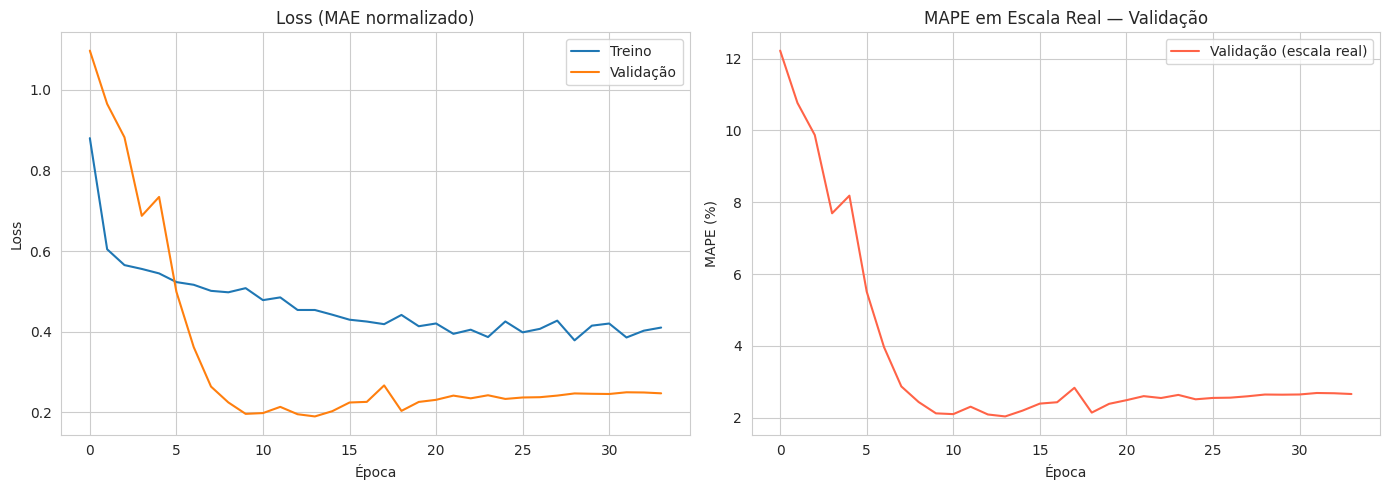

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Loss (MAE normalizado)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['val_mape_real'], label='Validação (escala real)', color='tomato')
axes[1].set_title('MAPE em Escala Real — Validação')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Avaliação do Modelo

In [41]:
def inverse_close(arr_1d, scaler, num_features):
    dummy = np.zeros((len(arr_1d), num_features))
    dummy[:, 0] = arr_1d
    return scaler.inverse_transform(dummy)[:, 0]


predictions = model.predict(X_test)

y_pred_orig = inverse_close(predictions.flatten(), scaler, num_features)
y_test_orig = inverse_close(y_test,                scaler, num_features)

mae     = mean_absolute_error(y_test_orig, y_pred_orig)
mse     = mean_squared_error(y_test_orig, y_pred_orig)
rmse    = np.sqrt(mse)
mape    = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
dir_acc = np.mean(
    np.sign(np.diff(y_test_orig)) == np.sign(np.diff(y_pred_orig))
) * 100

print('=' * 50)
print('  Avaliação do Modelo (Escala Original — BRL)')
print('=' * 50)
print(f'  MAE   (Erro Médio Absoluto):           R${mae:.4f}')
print(f'  RMSE  (Raiz do Erro Quadrático Médio): R${rmse:.4f}')
print(f'  MAPE  (Erro Percentual Médio):          {mape:.2f}%')
print(f'  Dir.  (Acurácia Direcional):            {dir_acc:.2f}%')
print('=' * 50)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
  Avaliação do Modelo (Escala Original — BRL)
  MAE   (Erro Médio Absoluto):           R$0.0297
  RMSE  (Raiz do Erro Quadrático Médio): R$0.0386
  MAPE  (Erro Percentual Médio):          1.94%
  Dir.  (Acurácia Direcional):            40.31%


### Baseline Naive — Random Walk

Comparamos o modelo com o preditor trivial de "prever o preço de ontem". Para séries de preço de ativos, esse baseline costuma ter MAPE de 1–2% e é o piso mínimo que qualquer modelo deve superar para ser considerado útil.

In [42]:
y_naive = y_test_orig[:-1]
y_actual_shifted = y_test_orig[1:]

mape_naive = np.mean(np.abs((y_actual_shifted - y_naive) / y_actual_shifted)) * 100

print('=' * 50)
print('  Baseline Naive (Random Walk)')
print('=' * 50)
print(f'  MAPE Naive:  {mape_naive:.2f}%')
print(f'  MAPE Modelo: {mape:.2f}%')
print(f'  Ganho:       {mape_naive - mape:.2f} p.p.')
print('=' * 50)

  Baseline Naive (Random Walk)
  MAPE Naive:  0.91%
  MAPE Modelo: 1.94%
  Ganho:       -1.03 p.p.


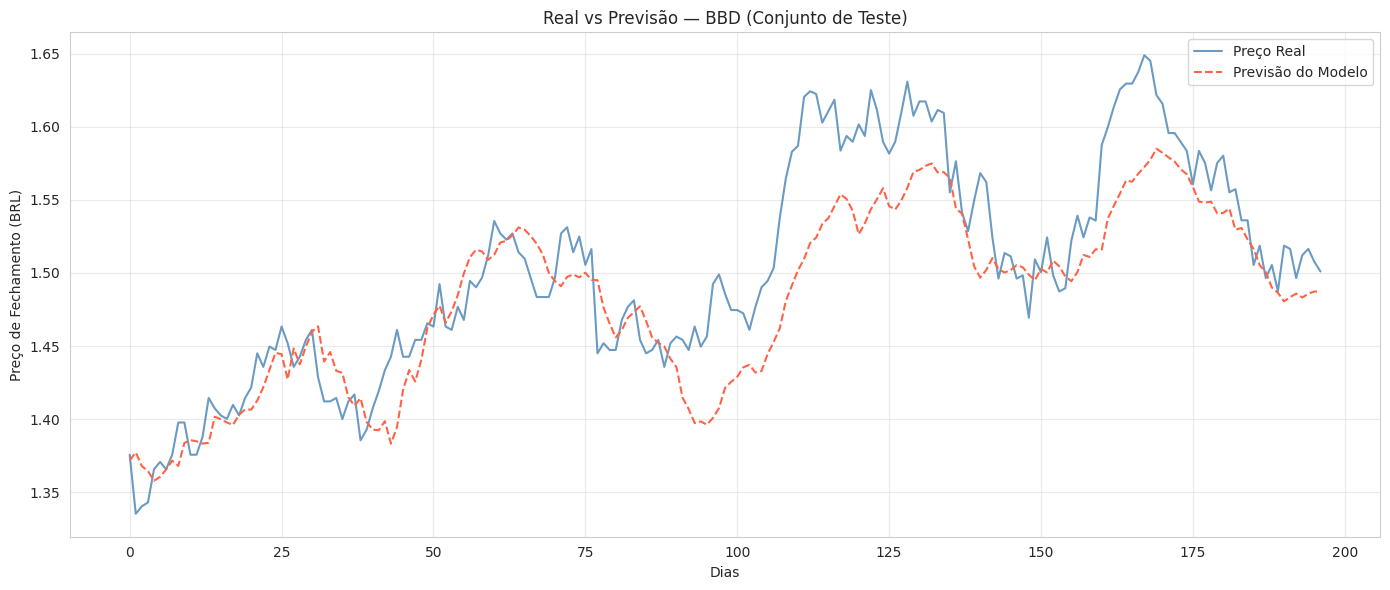

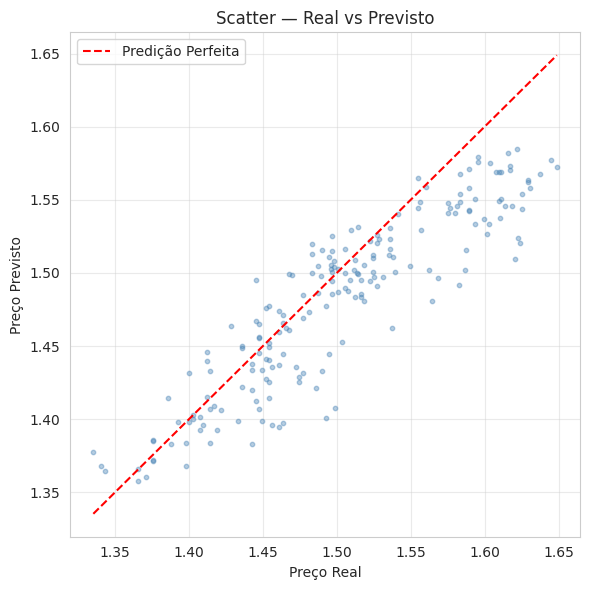

In [43]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_orig, label='Preço Real',         color='steelblue', alpha=0.8)
plt.plot(y_pred_orig, label='Previsão do Modelo', color='tomato', linestyle='--')
plt.title(f'Real vs Previsão — {symbol} (Conjunto de Teste)')
plt.xlabel('Dias')
plt.ylabel('Preço de Fechamento (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.4, color='steelblue', s=10)
lims = [min(y_test_orig.min(), y_pred_orig.min()),
        max(y_test_orig.max(), y_pred_orig.max())]
plt.plot(lims, lims, 'r--', lw=1.5, label='Predição Perfeita')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Scatter — Real vs Previsto')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Walk-Forward Validation

Complementa o split fixo avaliando o modelo em múltiplas janelas temporais deslizantes. Cada iteração retreina o modelo com os dados disponíveis até aquele ponto e avalia nos 30 dias seguintes, fornecendo uma estimativa de MAPE mais robusta e realista para uso em produção.

  Walk-Forward Validation
  Janelas avaliadas: 7
  MAPE médio:        2.39%
  MAPE desvio-pad.:  1.25%
  MAPE mínimo:       1.06%
  MAPE máximo:       4.89%


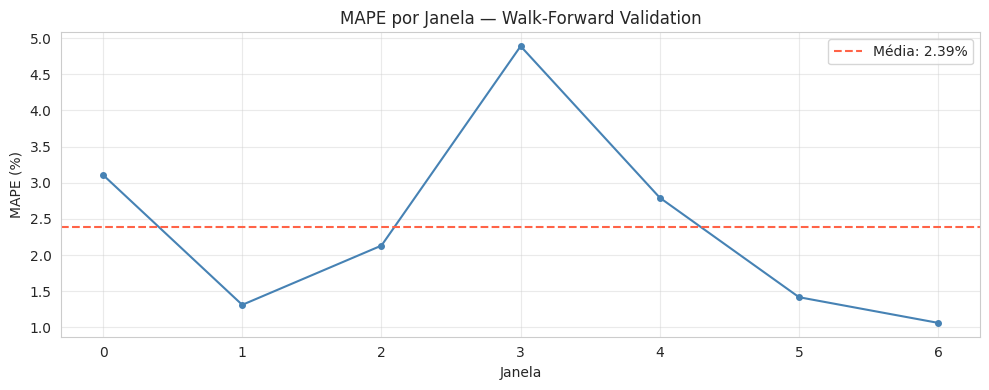

In [45]:
STEP        = 30
wf_mapes    = []
wf_start    = train_size + val_size

for start in range(wf_start, len(data) - STEP, STEP):
    wf_train_raw = data[:start]
    wf_test_raw  = data[start:start + STEP + LOOK_BACK]

    sc_wf         = StandardScaler()
    wf_train_sc   = sc_wf.fit_transform(wf_train_raw)
    wf_test_sc    = sc_wf.transform(wf_test_raw)

    Xw_tr, yw_tr = create_sequences(wf_train_sc, LOOK_BACK)
    Xw_te, yw_te = create_sequences(wf_test_sc,  LOOK_BACK)

    if len(Xw_tr) == 0 or len(Xw_te) == 0:
        continue

    m_wf = build_model(LOOK_BACK, num_features, BEST_UNITS, BEST_DROPOUT)
    m_wf.fit(
        Xw_tr, yw_tr,
        epochs=50,
        batch_size=BEST_BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='loss', patience=5, verbose=0)],
        verbose=0
    )

    preds_wf  = m_wf.predict(Xw_te, verbose=0).flatten()
    pred_orig = inverse_close(preds_wf,  sc_wf, num_features)
    true_orig = inverse_close(yw_te,     sc_wf, num_features)
    wf_mape   = np.mean(np.abs((true_orig - pred_orig) / true_orig)) * 100
    wf_mapes.append(wf_mape)

    tf.keras.backend.clear_session()

print('=' * 50)
print('  Walk-Forward Validation')
print('=' * 50)
print(f'  Janelas avaliadas: {len(wf_mapes)}')
print(f'  MAPE médio:        {np.mean(wf_mapes):.2f}%')
print(f'  MAPE desvio-pad.:  {np.std(wf_mapes):.2f}%')
print(f'  MAPE mínimo:       {np.min(wf_mapes):.2f}%')
print(f'  MAPE máximo:       {np.max(wf_mapes):.2f}%')
print('=' * 50)

plt.figure(figsize=(10, 4))
plt.plot(wf_mapes, marker='o', markersize=4, color='steelblue')
plt.axhline(np.mean(wf_mapes), color='tomato', linestyle='--', label=f'Média: {np.mean(wf_mapes):.2f}%')
plt.title('MAPE por Janela — Walk-Forward Validation')
plt.xlabel('Janela')
plt.ylabel('MAPE (%)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Previsão para o Próximo Dia (Produção)

Pipeline de inferência diária: busca os últimos `LOOK_BACK` dias de OHLCV via `yfinance`, recalcula todos os indicadores técnicos e features de calendário, aplica o `scaler` treinado e obtém o preço de fechamento previsto para o próximo pregão.

In [46]:
import datetime
import joblib

# ── Carregamento dos artefatos (para uso standalone / re-execução) ───────────
# Se model e scaler já estão em memória (execução sequencial do notebook),
# as linhas abaixo podem ser omitidas. Descomente-as para uso isolado.
MODEL_PATH  = 'modelo_lstm.keras'
SCALER_PATH = 'scaler.pkl'
model  = tf.keras.models.load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
FEATURE_COLS = ['Close', 'High', 'Low', 'Open', 'Volume']
symbol     = 'BBD'
LOOK_BACK = 30
num_features = 5


def prever_proximo_dia(symbol, look_back, scaler, model, num_features, feature_cols):
    """
    Busca exatamente `look_back` pregões válidos a partir de hoje e retorna
    o preço de fechamento previsto para o próximo pregão.

    Estratégia de janela:
      - Pregões ocorrem ~252 dias/ano → 1 pregão ≈ 365/252 ≈ 1.45 dias corridos.
      - Para garantir `look_back` pregões mesmo com feriados prolongados,
        pedimos look_back * 2 dias corridos (margem ~2×), descartamos NaNs
        e pegamos os últimos `look_back` registros válidos.
      - Se mesmo assim sobrarem menos de `look_back` pregões, levantamos
        ValueError com diagnóstico claro.
    """
    end_date   = datetime.date.today()
    # Margem de calendário: ~2 dias corridos por pregão garante cobertura
    # mesmo com semanas de feriados consecutivos.
    calendar_days = look_back * 2 + 10          # +10 dias de folga extra
    start_date = end_date - datetime.timedelta(days=calendar_days)

    raw = yf.download(symbol, start=start_date, end=end_date, progress=False)

    if raw.empty:
        raise ValueError(
            f'yfinance não retornou dados para {symbol!r} '
            f'entre {start_date} e {end_date}.'
        )

    # Normalizar MultiIndex retornado pelo yfinance
    raw.columns = raw.columns.get_level_values(0)
    raw.reset_index(inplace=True)

    # Pipeline idêntico ao pré-processamento de treino
    raw.dropna(inplace=True)
    raw.reset_index(drop=True, inplace=True)

    price_cols = ['Close', 'High', 'Low', 'Open']
    raw[price_cols] = np.log1p(raw[price_cols])
    raw['Volume']   = np.log1p(raw['Volume'])

    n_pregoes = len(raw)
    if n_pregoes < look_back:
        raise ValueError(
            f'Pregões insuficientes após limpeza: obtidos {n_pregoes}, '
            f'necessário {look_back}. '
            f'Tente aumentar `calendar_days` ou verifique o símbolo.'
        )

    # Janela de inferência: exatamente os últimos `look_back` pregões
    janela        = raw[feature_cols].values[-look_back:]   # shape (look_back, n_features)
    janela_scaled = scaler.transform(janela)                # aplica StandardScaler treinado
    X_input       = janela_scaled[np.newaxis, :, :]         # shape (1, look_back, n_features)

    pred_scaled = model.predict(X_input, verbose=0)         # saída normalizada

    # Inversão: StandardScaler → log1p → preço original
    dummy        = np.zeros((1, num_features))
    dummy[0, 0]  = pred_scaled[0, 0]
    preco_log    = scaler.inverse_transform(dummy)[0, 0]    # desfaz StandardScaler
    preco_real   = np.expm1(preco_log)                      # desfaz log1p

    ultimo_pregao = raw['Date'].iloc[-1]
    return float(preco_real), ultimo_pregao


# ── Execução ─────────────────────────────────────────────────────────────────
preco_amanha, ultimo_dia = prever_proximo_dia(
    symbol       = symbol,
    look_back    = LOOK_BACK,
    scaler       = scaler,
    model        = model,
    num_features = num_features,
    feature_cols = FEATURE_COLS
)

print('=' * 50)
print('  Previsão de Fechamento — Próximo Pregão')
print('=' * 50)
print(f'  Último pregão disponível : {ultimo_dia.date()}')
print(f'  Data de execução         : {datetime.date.today()}')
print(f'  Previsão para amanhã     : R$ {preco_amanha:.4f}')
print('=' * 50)


  Previsão de Fechamento — Próximo Pregão
  Último pregão disponível : 2026-06-26
  Data de execução         : 2026-06-27
  Previsão para amanhã     : R$ 3.3058
